In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import time
import json
import pickle
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, GridSearchCV,RandomizedSearchCV, cross_val_score,cross_validate, StratifiedKFold)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, classification_report, confusion_matrix)
import xgboost as xgb
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern, hog
from scipy.stats import skew, ttest_rel
from sklearn.model_selection import StratifiedKFold


In [2]:
np.random.seed(42)

In [3]:
DATASET_PATH = r""
class_folders = sorted([f for f in os.listdir(DATASET_PATH)
                        if os.path.isdir(os.path.join(DATASET_PATH, f))])
print(f"✓ Path ditemukan!")
print(f"Found {len(class_folders)} classes:")
for i, cls in enumerate(class_folders, 1):
    count = len(glob.glob(os.path.join(DATASET_PATH, cls, '*.*')))
    print(f"  {i}. {cls}: {count} images")
    total = sum([len(glob.glob(os.path.join(DATASET_PATH, cls, '*.*')))
                 for cls in class_folders])
    print(f"\nTotal images: {total}")

✓ Path ditemukan!
Found 4 classes:
  1. Visualisasi: 4 images

Total images: 12
  2. hasil_visualisasi: 8 images

Total images: 12
  3. test: 0 images

Total images: 12
  4. train: 0 images

Total images: 12


In [4]:
train = pd.read_csv(
    "fitur_train_normalized.csv"
)

test = pd.read_csv(
    "fitur_test_normalized.csv"
)

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

train.head()

Train Shape : (24000, 218)
Test Shape  : (1200, 218)


,0,1,2,3,4,5,6,7,8,9,...,208,209,210,211,212,213,214,215,216,label
0,-0.539216,-0.392836,-0.584535,-0.734448,-0.820765,-0.826281,-0.881021,-0.987343,-1.088156,-0.992054,...,-0.376391,0.580271,-1.008908,0.646663,-0.766566,0.388479,0.673555,0.022022,0.0161,bacterial_spot
1,-0.539216,-0.392836,-0.584535,-0.740889,-0.828523,-0.842209,-0.889480,-0.992002,-1.092891,-1.044554,...,-0.940739,0.606949,-1.094107,0.718623,-1.377268,0.319861,0.831374,0.183035,0.0161,bacterial_spot
2,-0.539216,-0.392836,-0.584535,-0.740889,-0.828523,-0.839411,-0.885578,-0.992247,-1.106443,-1.112399,...,-1.036943,0.602944,-1.082186,0.449320,-1.444833,0.368462,0.762530,0.101965,0.0161,bacterial_spot
3,-0.539216,-0.392836,-0.584535,-0.734449,-0.820767,-0.827418,-0.879986,-0.987888,-1.086476,-0.991539,...,-0.376864,0.561750,-0.948995,0.646800,-0.765726,0.388183,0.675056,0.023326,0.0161,bacterial_spot
4,0.328621,-0.363123,-0.560814,-0.716129,-0.803445,-0.818125,-0.867639,-0.969681,-1.074305,-1.089083,...,0.328012,0.402359,-0.444032,0.337358,-0.292024,1.009102,-0.930737,-0.961349,0.0161,bacterial_spot


In [5]:
X_train = train.drop(
    columns=["label"]
)
y_train = train["label"]
X_test = test.drop(
    columns=["label"]
)
y_test = test["label"]
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)
le = LabelEncoder()
y_train = le.fit_transform(
    y_train
)
y_test = le.transform(
    y_test
)
class_folders = list(
    le.classes_
)
print("\nJumlah Kelas :", len(class_folders))
for i, cls in enumerate(class_folders):
    print(f"{i} -> {cls}")

X_train : (24000, 217)
X_test  : (1200, 217)
y_train : (24000,)
y_test  : (1200,)

Jumlah Kelas : 8
0 -> bacterial_spot
1 -> early_blight
2 -> healthy
3 -> late_blight
4 -> mosaic_virus
5 -> septoria_leaf_spot
6 -> spotted_spider_mite
7 -> target_spot


In [6]:
X_train_scaled = X_train.values
X_test_scaled = X_test.values

print("Train Feature :", X_train_scaled.shape)
print("Test Feature  :", X_test_scaled.shape)

with open(
    "label_encoder.pkl",
    "wb"
) as f:
    pickle.dump(
        le,
        f
    )
print("\nLabel Encoder disimpan")
print("Missing Value Train :")
print(X_train.isnull().sum().sum())
print()
print("Missing Value Test :")
print(X_test.isnull().sum().sum())
print()
print("Jumlah Kelas Train :")
print(pd.Series(y_train).value_counts())
print()
print("Jumlah Kelas Test :")
print(pd.Series(y_test).value_counts())

Train Feature : (24000, 217)
Test Feature  : (1200, 217)

Label Encoder disimpan
Missing Value Train :
0

Missing Value Test :
0

Jumlah Kelas Train :
0    3000
1    3000
2    3000
3    3000
4    3000
5    3000
6    3000
7    3000
Name: count, dtype: int64

Jumlah Kelas Test :
0    150
1    150
2    150
3    150
4    150
5    150
6    150
7    150
Name: count, dtype: int64


In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("StratifiedKFold berhasil dibuat")
print("Jumlah Fold :", cv.get_n_splits())

StratifiedKFold berhasil dibuat
Jumlah Fold : 5


In [8]:
print("="*60)
print("HYPERPARAMETER TUNING - RANDOM FOREST")
print("="*60)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Memulai Randomized Search RF...")

rf_start_time = time.time()

rf_random_search.fit(
    X_train_scaled,
    y_train
)

rf_tuning_time = time.time() - rf_start_time

print(f"\n✓ Hyperparameter tuning Random Forest selesai!")
print(f"  - Waktu tuning: {rf_tuning_time:.2f} detik ({rf_tuning_time/60:.2f} menit)")
print(f"  - Best parameters: {rf_random_search.best_params_}")
print(f"  - Best CV accuracy: {rf_random_search.best_score_*100:.4f}%")

HYPERPARAMETER TUNING - RANDOM FOREST
Memulai Randomized Search RF...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Hyperparameter tuning Random Forest selesai!
  - Waktu tuning: 774.57 detik (12.91 menit)
  - Best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
  - Best CV accuracy: 96.2750%


In [9]:
final_rf = RandomForestClassifier(**rf_random_search.best_params_, random_state=42, n_jobs=-1)

print("Training final Random Forest model...")
rf_train_start = time.time()
final_rf.fit(X_train_scaled, y_train)
rf_training_time = time.time() - rf_train_start
print(f"✓ Training selesai dalam {rf_training_time:.4f} detik")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_results = cross_validate(
    final_rf, X_train_scaled, y_train, cv=cv,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    return_train_score=True
)

print(f"\nCross-Validation Results (Random Forest):")
print(f"  CV Accuracy:  {rf_cv_results['test_accuracy'].mean()*100:.4f}% (+/- {rf_cv_results['test_accuracy'].std()*100:.4f}%)")
print(f"  CV Precision: {rf_cv_results['test_precision_macro'].mean()*100:.4f}%")
print(f"  CV Recall:    {rf_cv_results['test_recall_macro'].mean()*100:.4f}%")
print(f"  CV F1-Score:  {rf_cv_results['test_f1_macro'].mean()*100:.4f}%")

rf_inference_start = time.time()
_ = final_rf.predict(X_test_scaled)
rf_inference_total = time.time() - rf_inference_start
rf_inference_per_sample = (rf_inference_total / len(X_test_scaled)) * 1000

print(f"\nInference Time Random Forest: {rf_inference_per_sample:.4f} ms/sample")

rf_model_size = len(pickle.dumps(final_rf)) / (1024 * 1024)
print(f"Model Size Random Forest: {rf_model_size:.2f} MB")

with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(final_rf, f)
print(f"\n✓ Model Random Forest disimpan!")

Training final Random Forest model...
✓ Training selesai dalam 20.4844 detik

Cross-Validation Results (Random Forest):
  CV Accuracy:  96.2750% (+/- 0.3419%)
  CV Precision: 96.2923%
  CV Recall:    96.2750%
  CV F1-Score:  96.2627%

Inference Time Random Forest: 0.0761 ms/sample
Model Size Random Forest: 117.12 MB

✓ Model Random Forest disimpan!


In [10]:
XGB_DEVICE = "cpu"

try:
    test_model = xgb.XGBClassifier(
        n_estimators=10,
        tree_method="hist",
        device="cuda",
        verbosity=0
    )

    test_model.fit(
        X_train_scaled[:50],
        y_train[:50]
    )

    XGB_DEVICE = "cuda"

    print("GPU NVIDIA terdeteksi")
    print("XGBoost menggunakan GPU")

except Exception as e:

    XGB_DEVICE = "cpu"

    print("GPU tidak tersedia")
    print("XGBoost menggunakan CPU")
    print(e)

print(f"Device aktif : {XGB_DEVICE}")

GPU NVIDIA terdeteksi
XGBoost menggunakan GPU
Device aktif : cuda


In [11]:
print("="*60)
print("HYPERPARAMETER TUNING - XGBOOST")
print("="*60)

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}

xgb_base = xgb.XGBClassifier(
    random_state=42, n_jobs=-1,
    tree_method='hist', device=XGB_DEVICE,  
    objective='multi:softmax', num_class=len(class_folders),
    eval_metric='mlogloss', verbosity=0
)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base, param_distributions=xgb_param_grid,
    n_iter=20, cv=cv, scoring='accuracy',
    n_jobs=1 if XGB_DEVICE == 'cuda' else -1,  
    random_state=42, verbose=1
)

print("Memulai Randomized Search (50 iterasi)...")
xgb_start_time = time.time()
xgb_random_search.fit(X_train_scaled, y_train)
xgb_tuning_time = time.time() - xgb_start_time

print(f"\n✓ Hyperparameter tuning XGBoost selesai!")
print(f"  - Waktu tuning: {xgb_tuning_time:.2f} detik ({xgb_tuning_time/60:.2f} menit)")
print(f"  - Best parameters: {xgb_random_search.best_params_}")
print(f"  - Best CV accuracy: {xgb_random_search.best_score_*100:.4f}%")

HYPERPARAMETER TUNING - XGBOOST
Memulai Randomized Search (50 iterasi)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Hyperparameter tuning XGBoost selesai!
  - Waktu tuning: 1334.55 detik (22.24 menit)
  - Best parameters: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
  - Best CV accuracy: 98.1875%


In [12]:
final_xgb = xgb.XGBClassifier(
    **xgb_random_search.best_params_, random_state=42, n_jobs=-1,
    tree_method='hist', device=XGB_DEVICE,
    objective='multi:softmax',
    num_class=len(class_folders), eval_metric='mlogloss', verbosity=0
)

print("Training final XGBoost model...")
xgb_train_start = time.time()
final_xgb.fit(X_train_scaled, y_train)
xgb_training_time = time.time() - xgb_train_start
print(f"✓ Training selesai dalam {xgb_training_time:.4f} detik")

xgb_cv_results = cross_validate(
    final_xgb, X_train_scaled, y_train, cv=cv,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    return_train_score=True
)

print(f"\nCross-Validation Results (XGBoost):")
print(f"  CV Accuracy:  {xgb_cv_results['test_accuracy'].mean()*100:.4f}% (+/- {xgb_cv_results['test_accuracy'].std()*100:.4f}%)")
print(f"  CV Precision: {xgb_cv_results['test_precision_macro'].mean()*100:.4f}%")
print(f"  CV Recall:    {xgb_cv_results['test_recall_macro'].mean()*100:.4f}%")
print(f"  CV F1-Score:  {xgb_cv_results['test_f1_macro'].mean()*100:.4f}%")

xgb_inference_start = time.time()
_ = final_xgb.predict(X_test_scaled)
xgb_inference_total = time.time() - xgb_inference_start
xgb_inference_per_sample = (xgb_inference_total / len(X_test_scaled)) * 1000

print(f"\nInference Time XGBoost: {xgb_inference_per_sample:.4f} ms/sample")

xgb_model_size = len(pickle.dumps(final_xgb)) / (1024 * 1024)
print(f"Model Size XGBoost: {xgb_model_size:.2f} MB")

with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(final_xgb, f)
print(f"\n✓ Model XGBoost disimpan!")

Training final XGBoost model...
✓ Training selesai dalam 18.7840 detik

Cross-Validation Results (XGBoost):
  CV Accuracy:  98.1875% (+/- 0.1304%)
  CV Precision: 98.1920%
  CV Recall:    98.1875%
  CV F1-Score:  98.1858%

Inference Time XGBoost: 0.1264 ms/sample
Model Size XGBoost: 6.58 MB

✓ Model XGBoost disimpan!


In [13]:
print("="*60)
print("EVALUASI PADA TESTING SET")
print("="*60)

rf_predictions = final_rf.predict(X_test_scaled)
xgb_predictions = final_xgb.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions, average='macro', zero_division=0)
rf_recall = recall_score(y_test, rf_predictions, average='macro', zero_division=0)
rf_f1 = f1_score(y_test, rf_predictions, average='macro', zero_division=0)

xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions, average='macro', zero_division=0)
xgb_recall = recall_score(y_test, xgb_predictions, average='macro', zero_division=0)
xgb_f1 = f1_score(y_test, xgb_predictions, average='macro', zero_division=0)

print("\n" + "="*70)
print(f"{'Metrik':<25} {'Random Forest':>20} {'XGBoost':>20}")
print("="*70)
print(f"{'Accuracy':<25} {rf_accuracy*100:>19.4f}% {xgb_accuracy*100:>19.4f}%")
print(f"{'Precision (Macro)':<25} {rf_precision*100:>19.4f}% {xgb_precision*100:>19.4f}%")
print(f"{'Recall (Macro)':<25} {rf_recall*100:>19.4f}% {xgb_recall*100:>19.4f}%")
print(f"{'F1-Score (Macro)':<25} {rf_f1*100:>19.4f}% {xgb_f1*100:>19.4f}%")
print(f"{'Training Time':<25} {rf_training_time:>18.4f}s {xgb_training_time:>18.4f}s")
print(f"{'Inference Time/Sample':<25} {rf_inference_per_sample:>17.4f}ms {xgb_inference_per_sample:>17.4f}ms")
print(f"{'Model Size':<25} {rf_model_size:>18.2f}MB {xgb_model_size:>18.2f}MB")
print("="*70)

print("\n--- Classification Report: RANDOM FOREST ---")
print(classification_report(y_test, rf_predictions, target_names=class_folders, digits=4))

print("\n--- Classification Report: XGBOOST ---")
print(classification_report(y_test, xgb_predictions, target_names=class_folders, digits=4))

EVALUASI PADA TESTING SET

Metrik                           Random Forest              XGBoost
Accuracy                              88.5833%             91.1667%
Precision (Macro)                     88.8344%             91.4863%
Recall (Macro)                        88.5833%             91.1667%
F1-Score (Macro)                      88.5838%             91.2263%
Training Time                        20.4844s            18.7840s
Inference Time/Sample                0.0761ms            0.1264ms
Model Size                            117.12MB               6.58MB

--- Classification Report: RANDOM FOREST ---
                     precision    recall  f1-score   support

     bacterial_spot     0.9724    0.9400    0.9559       150
       early_blight     0.7778    0.7933    0.7855       150
            healthy     0.8571    0.7600    0.8057       150
        late_blight     0.7976    0.8933    0.8428       150
       mosaic_virus     0.8780    0.9600    0.9172       150
 septoria_leaf_spot 

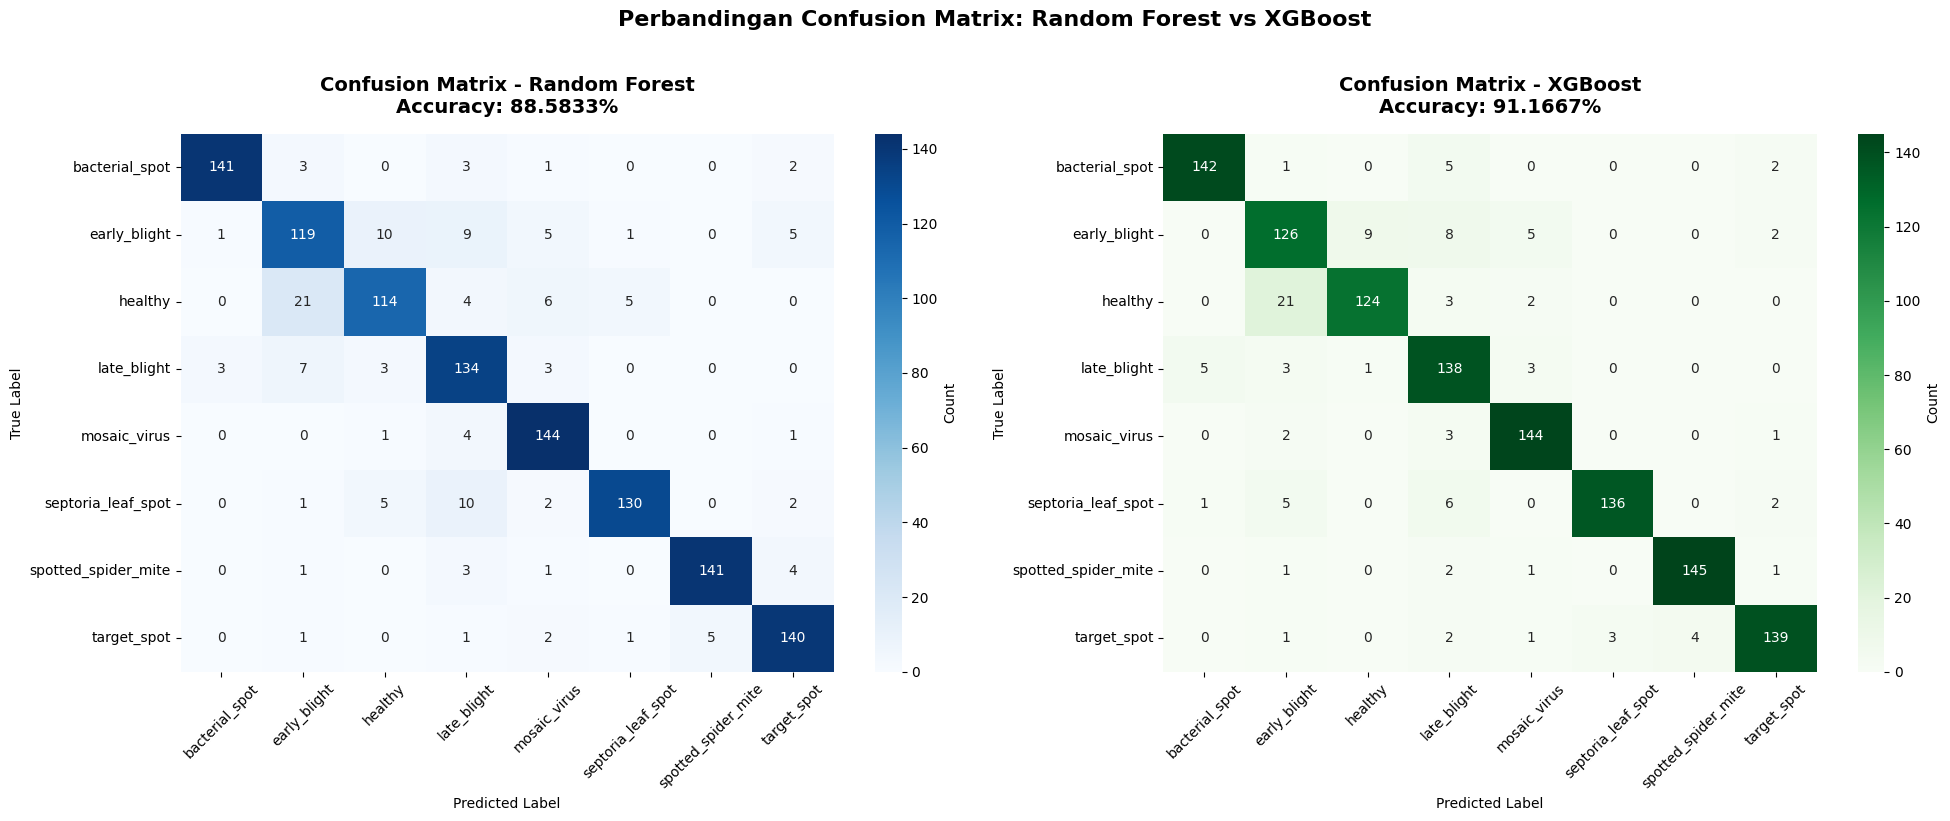

Confusion Matrix berhasil disimpan
✓ Confusion Matrix disimpan!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm_rf = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_folders, yticklabels=class_folders,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'Confusion Matrix - Random Forest\nAccuracy: {rf_accuracy*100:.4f}%',
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

cm_xgb = confusion_matrix(y_test, xgb_predictions)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_folders, yticklabels=class_folders,
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'Confusion Matrix - XGBoost\nAccuracy: {xgb_accuracy*100:.4f}%',
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Perbandingan Confusion Matrix: Random Forest vs XGBoost', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

pd.DataFrame(
    cm_rf,
    index=class_folders,
    columns=class_folders
).to_csv(
    "confusion_matrix_rf.csv"
)
pd.DataFrame(
    cm_xgb,
    index=class_folders,
    columns=class_folders
).to_csv(
    "confusion_matrix_xgb.csv"
)

print("Confusion Matrix berhasil disimpan")
print("✓ Confusion Matrix disimpan!")

In [15]:
print("="*60)
print("STATISTICAL SIGNIFICANCE TESTING")
print("="*60)

rf_cv_scores = cross_val_score(final_rf, X_train_scaled, y_train, cv=cv, scoring='accuracy')
xgb_cv_scores = cross_val_score(final_xgb, X_train_scaled, y_train, cv=cv, scoring='accuracy')

t_stat, p_value = ttest_rel(rf_cv_scores, xgb_cv_scores)

print(f"\nRandom Forest CV Scores: {rf_cv_scores}")
print(f"XGBoost CV Scores: {xgb_cv_scores}")
print(f"\nPaired t-test Results:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.05:
    winner = "Random Forest" if rf_cv_scores.mean() > xgb_cv_scores.mean() else "XGBoost"
    print(f"\n✓ Perbedaan SIGNIFIKAN (p={p_value:.4f} < 0.05). {winner} lebih superior secara statistik.")
else:
    print(f"\n⚠ Perbedaan TIDAK SIGNIFIKAN (p={p_value:.4f} >= 0.05). Kedua algoritma perform similarly.")

STATISTICAL SIGNIFICANCE TESTING

Random Forest CV Scores: [0.96583333 0.96729167 0.95833333 0.9625     0.95979167]
XGBoost CV Scores: [0.98333333 0.98291667 0.98020833 0.98041667 0.9825    ]

Paired t-test Results:
  t-statistic: -14.1081
  p-value: 0.0001

✓ Perbedaan SIGNIFIKAN (p=0.0001 < 0.05). XGBoost lebih superior secara statistik.


In [16]:
results = {
    'dataset': {
        'total_samples': int(len(X_train) + len(X_test)),
        'n_features': int(X_train.shape[1]),
        'n_classes': int(len(np.unique(y_train))),
        'train_size': int(len(X_train)),
        'test_size': int(len(X_test))
    },

    'random_forest': {
        'best_params': rf_random_search.best_params_,
        'cv_accuracy_mean': float(rf_cv_results['test_accuracy'].mean()),
        'cv_accuracy_std': float(rf_cv_results['test_accuracy'].std()),
        'test_accuracy': float(rf_accuracy),
        'test_precision': float(rf_precision),
        'test_recall': float(rf_recall),
        'test_f1': float(rf_f1),
        'training_time': float(rf_training_time),
        'inference_time_ms': float(rf_inference_per_sample),
        'model_size_mb': float(rf_model_size)
    },

    'xgboost': {
        'best_params': xgb_random_search.best_params_,
        'cv_accuracy_mean': float(xgb_cv_results['test_accuracy'].mean()),
        'cv_accuracy_std': float(xgb_cv_results['test_accuracy'].std()),
        'test_accuracy': float(xgb_accuracy),
        'test_precision': float(xgb_precision),
        'test_recall': float(xgb_recall),
        'test_f1': float(xgb_f1),
        'training_time': float(xgb_training_time),
        'inference_time_ms': float(xgb_inference_per_sample),
        'model_size_mb': float(xgb_model_size)
    },

    'statistical_testing': {
        't_statistic': float(t_stat),
        'p_value': float(p_value),
        'significant': bool(p_value < 0.05)
    }
}

with open('comparison_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("✓ Hasil disimpan ke comparison_results.json")
print("✓ TAHAP PERBANDINGAN SELESAI!")

✓ Hasil disimpan ke comparison_results.json
✓ TAHAP PERBANDINGAN SELESAI!
